In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from pathlib import Path
import pynapple as nap

from scipy.stats import gaussian_kde

from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.data.loading import load_session
from spatial_manifolds.detect_grids import *
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


In [ ]:
# Load session
gcs_ = pd.DataFrame()
ngs_ = pd.DataFrame()
ns_ = pd.DataFrame()
sc_ = pd.DataFrame()
ngs_ns_ = pd.DataFrame()
all_ = pd.DataFrame()

mouse_days = {20: [14,15,16,17,18,19,20,21,22,23,24,25,26],
              21: [15,16,17,18,19,20,21,22,23,24,25,26],
              25: [16,17,18,19,20,21,22,23,24,25],
              26: [11,12,13,14,15,16,17,18,19],
              27: [16,17,18,19,20,21,22,23,24,26],
              28: [16,17,18,19,20,21,22,23,25],
              29: [16,17,18,19,20,21,22,23,25],
            }

for use_optimal_travel in [True, False]:
    for mouse, days in mouse_days.items():
        for day in days:

            # remove M22 
            if mouse == 22:
                continue

            [gcs, ngs, ns, sc, ngs_ns, all] = cell_classification_of1(mouse, day, use_optimal_travel=use_optimal_travel)
            _,_,_,_,_,clusters_VR = compute_vr_tcs(mouse, day)

            # add columns for all cells whether the use_optimal_travel is True or False
            for cells in [gcs, ngs, ns, sc, ngs_ns, all]:
                cells['use_optimal_travel'] = np.repeat(use_optimal_travel, len(cells))
                
            gcs = load_cluster_locations(clusters_VR, cells=gcs)
            ngs = load_cluster_locations(clusters_VR, cells=ngs)
            ns = load_cluster_locations(clusters_VR, cells=ns)
            sc = load_cluster_locations(clusters_VR, cells=sc)
            ngs_ns = load_cluster_locations(clusters_VR, cells=ngs_ns)
            all = load_cluster_locations(clusters_VR, cells=all)
            
            gcs_ = pd.concat([gcs_, gcs], ignore_index=True)
            ngs_ = pd.concat([ngs_, ngs], ignore_index=True)
            ns_ = pd.concat([ns_, ns], ignore_index=True)
            sc_ = pd.concat([sc_, sc], ignore_index=True)
            ngs_ns_ = pd.concat([ngs_ns_, ngs_ns], ignore_index=True)
            all_ = pd.concat([all_, all], ignore_index=True)

        print(f'there are this many cells at the moment, {len(all_)}')

20 14
there are 169 non_grid and non_spatial_cells
there are 0 grid_cells
there are 93 non grid spatial cells
there are 76 non spatial cells
there are 35 speed cells
there are 204 cells
for the non-grid spatial cells the unique locations are ['ENTm1' 'ENTm2' 'ENTm3' 'ENTm5']
20 15
there are 61 non_grid and non_spatial_cells
there are 1 grid_cells
there are 50 non grid spatial cells
there are 11 non spatial cells
there are 11 speed cells
there are 73 cells
for the non-grid spatial cells the unique locations are ['ENTm2' 'ENTm3' 'ENTm5']
for the grid cells the unique locations are ['ENTm3']
20 16
there are 178 non_grid and non_spatial_cells
there are 3 grid_cells
there are 156 non grid spatial cells
there are 22 non spatial cells
there are 38 speed cells
there are 219 cells
for the non-grid spatial cells the unique locations are ['ENTm3']
for the grid cells the unique locations are ['ENTm3']
20 17
there are 112 non_grid and non_spatial_cells
there are 3 grid_cells
there are 88 non grid s

Grid cells have been shown to be predictive in their spatial coding. That is to say if the future position is to be considered instead of the present position, spatial coding metrics like the grid score is optimal at some offset position along the trajectory of the animal.

We asked whether this is also true for non-grid MEC cells.

Firstly, as spatial cells are typically classified using the spatial information score, we asked whether the spatial information score could be used similarly to grid score to look for improved spatial coding given some offset position along the mouse's trajectory

We computed grid scores and spatial information scores across lags between -50 and 50 centrimetres for both grid cells and non-grid cells

We found ... 

that there was a similar optimal lag in the spatial information score as was seen in the grid score for grid cells. This is reflective of the shared properties of the grid and spatial information score, in that, both scores will be higher when spikes cluster together in space (or 'future space'). Furthermore, non grid cells also showed a similar optimal lag as their simulatenously recorded grid cell counterparts.

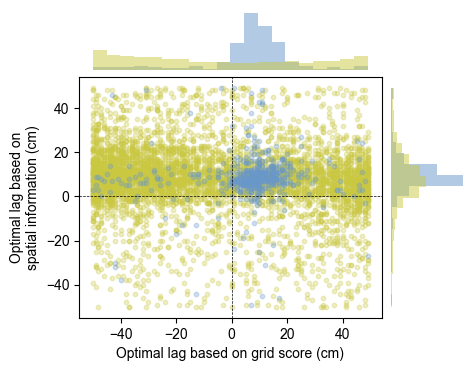

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec

# Prepare data
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()

# keep only mec ngs 
ngs_df = ngs_df[ngs_df['brain_region'].str.contains('ENT')]

gcs_df['group'] = 'GCS'
ngs_df['group'] = 'NGS'
combined = pd.concat([gcs_df, ngs_df], ignore_index=True)

# Set up the figure with GridSpec
fig = plt.figure(figsize=(5, 4))
gs = GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4], wspace=0.05, hspace=0.05)

ax_main = fig.add_subplot(gs[1, 0])
ax_xhist = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_yhist = fig.add_subplot(gs[1, 1], sharey=ax_main)

ax_main.scatter(ngs_df['optimal_travel_lag_grid_score'], ngs_df['optimal_travel_lag'], color='#CAC841', alpha=0.3, s=10)
ax_main.scatter(gcs_df['optimal_travel_lag_grid_score'], gcs_df['optimal_travel_lag'], color='#6897CD', alpha=0.3, s=10)

ax_main.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax_main.axvline(0, color='black', linewidth=0.5, linestyle='--')
ax_main.set_xlabel('Optimal lag based on grid score (cm)')
ax_main.set_ylabel('Optimal lag based on\nspatial information (cm)')

# X-axis histogram (top, horizontal bars)
for group, color in zip(['GCS', 'NGS'], ['#6897CD', '#CAC841']):
    ax_xhist.hist(
        combined[combined['group'] == group]['optimal_travel_lag_grid_score'], density=True,
        bins=20, color=color, alpha=0.5, orientation='vertical', histtype='bar', linewidth=1
    )
ax_xhist.axis('off')

# Y-axis histogram (right, horizontal bars)
for group, color in zip(['GCS', 'NGS'], ['#6897CD', '#CAC841']):
    ax_yhist.hist(
        combined[combined['group'] == group]['optimal_travel_lag'], density=True,
        bins=20, color=color, alpha=0.5, orientation='horizontal', histtype='bar', linewidth=1
    )
ax_yhist.axis('off')

fig.tight_layout()
plt.show()

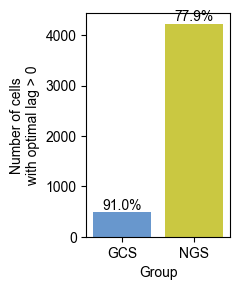

In [39]:
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()
gcs_df['group'] = 'GCS'
ngs_df['group'] = 'NGS'
combined = pd.concat([gcs_df, ngs_df], ignore_index=True)

# Count cells with optimal lag > 0 for each group
counts = combined.groupby('group')['optimal_travel_lag'].apply(lambda x: (x > 0).sum())
total = combined.groupby('group')['optimal_travel_lag'].count()
percent = (counts / total * 100).round(1)

# Bar plot
fig, ax = plt.subplots(figsize=(2.5, 3))
bars = ax.bar(counts.index, counts.values, color=['#6897CD', '#CAC841'])
ax.set_ylabel('Number of cells\nwith optimal lag > 0')
ax.set_xlabel('Group')

# Annotate percentage on bars
for bar, pct in zip(bars, percent):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{pct}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

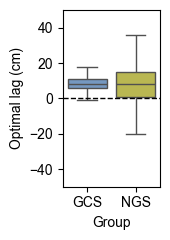

In [5]:
gcs_df = gcs_.copy()
ngs_df = ngs_.copy() 
# Add group labels
gcs_df['group'] = 'GCS'
ngs_df['group'] = 'NGS'

# Combine data
combined = pd.concat([gcs_df, ngs_df], ignore_index=True)

# Create boxplot
plt.figure(figsize=(1.8, 2.5))
sns.boxplot(data=combined, x='group', y='optimal_travel_lag', palette={'GCS': '#6897CD', 'NGS': '#CAC841'}, showfliers=False)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Group')
plt.ylabel('Optimal lag (cm)')
plt.ylim(-50, 50)
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Desktop/Nature2026 Figs/Figure2_predictive_coding_plots/optimal_spatial_information_lag_by_cell_type.pdf', bbox_inches='tight')
plt.show()


We computed the optimal lag at both a session and single cell level for the different brain regions recorded from, primarily the MEC, parasubiculum, visual cortex and cerebellum. 
 
We found ...

We then asked whether there was an anatomical arrangement of predictive coding in the MEC similar to the non-uniform distribution of grid cells along the medial-lateral MEC axis.

We found ....

In [ ]:
import seaborn as sns
gcs_df = gcs_.copy()
ngs_df = ngs_.copy()    

# Define bins and labels
bins = np.arange(2500, 4000, 250)
bins = np.append(bins, 3750)
bins = np.unique(bins)
labels = [f'{int(b)}-{int(b+250)}' for b in bins[:-1]]

# Bin the data
gcs_df['bin'] = pd.cut(gcs_df['coord_SCs_x']*-1, bins=bins, labels=labels, include_lowest=True)
ngs_df['bin'] = pd.cut(ngs_df['coord_SCs_x']*-1, bins=bins, labels=labels, include_lowest=True)

# Add group labels and reset index to avoid duplicate index issues
gcs_df['group'] = 'GCS'
ngs_df['group'] = 'NGS'
gcs_df.reset_index(drop=True, inplace=True)
ngs_df.reset_index(drop=True, inplace=True)

# Combine data for plotting
combined = pd.concat([gcs_df, ngs_df], ignore_index=True)

# Create a combined boxplot
plt.figure(figsize=(5, 2.5))
bp = sns.boxplot(data=combined, x='bin', y='optimal_travel_lag', 
            hue='group',palette={'GCS': '#6897CD', 'NGS': '#CAC841'}, showfliers=False)

for patch in bp.artists:
    patch.set_alpha(0.5)

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Medial-lateral (ML) Bins (um)')
plt.ylabel('Optimal lag (cm)')
plt.ylim(-50, 50)
plt.tight_layout()
plt.savefig(f'/Users/harryclark/Desktop/Nature2026 Figs/Figure1_plots/optimal_spatial_information_lag_ML.pdf', bbox_inches='tight')
plt.show()
